# tmp — mar25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

In [3]:
model_type = 'poisson'
npix = 16
cfg_vae, cfg_tr = default_configs(model_type, f'BALLS{npix}')

cfg_vae['n_latents'] = npix * 2

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 8.0

cfg_tr['lr'] = 2e-3

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")

poisson_BALLS16_t-16_z-[32]_cl-10,10_<grad|lin>
b400-ep1000-lr(0.002)_beta(8:0.1)_temp(0.01:0.5)_gr(10000)_(2025_03_02,16:22)

In [5]:
cm = 'DecClamp:3.45+HighestLR'
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 1000, avg loss: -433.024: 100%|███| 1000/1000 [2:55:29<00:00, 10.53s/it]


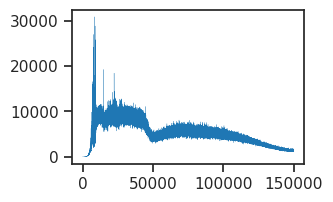

In [6]:
grads = (tr.stats['grad'].values())
plt.plot(grads, lw=0.2)

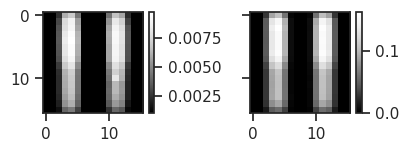

In [7]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

In [8]:
var_learned.min()

0.0010204786

In [9]:
from base.helper import find_weight_concentrations
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

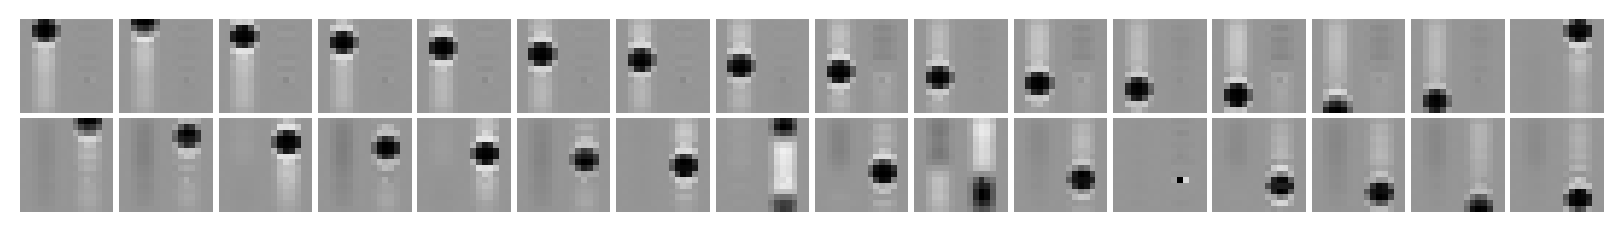

In [10]:
w = tr.model.layer.get_weight()
w = tonp(w.T).reshape(32, 16, 16)
ordered_indices, centers = find_weight_concentrations(
    w, lambda p: p[0] + (p[1] > 6).astype(float) * 50)

tr.model.show(order=ordered_indices, nrows=2, method='abs-max', cmap='Greys');

In [11]:
%%time


seq_total = 1000
selection = ['u', 'samples', 'r2']

kws_dl = dict(
    batch_size=1000,
    drop_last=False,
    shuffle=False,
)

results = {}
for item in ['trn', 'vld', 'tst']:
    # create data loader without shuffle
    ds = getattr(tr, f"dl_{item}").dataset
    dl = torch.utils.data.DataLoader(ds, **kws_dl)
    data = collections.defaultdict(list)
    for x, g in tqdm(iter(dl)):
        output = tr.model.xtract_ftr(
            feeder=tr.get_feeder(x),
            seq=range(seq_total),
            return_extras=True,
        ).stack()
        data['g'].append(g)
        for key in selection:
            data[key].append(output[key][:, -1])
        data['lamb'].append(output['u'][:, -1].exp())
    data = {
        k: tonp(torch.cat(v)) for
        k, v in data.items()
    }
    results[item] = data

100%|███████████████████████████████████████████| 50/50 [01:58<00:00,  2.38s/it]

CPU times: user 5min 9s, sys: 371 ms, total: 5min 10s
Wall time: 5min 9s


In [12]:
var = 'lamb'

lr = LinearRegression().fit(
    X=results['trn'][var],
    y=results['trn']['g'][:, [1, 3]],
)
r2 = {
    name: r2_score(
        y_true=d['g'][:, [1, 3]],
        y_pred=lr.predict(d[var]),
        multioutput='raw_values')
    for name, d in results.items()
}
corr = {
    name: 1 - np.diag(sp_dist.cdist(
        XA=d['g'][:, [1, 3]].T,
        XB=lr.predict(d[var]).T,
        metric='correlation',
    )) for name, d in results.items()
}

In [13]:
print(f"r2:", r2, '\nCorr:', corr)

r2:
{
    'trn': array([0.99583811, 0.99508268]),
    'vld': array([0.99582312, 0.9949118 ]),
    'tst': array([0.96691894, 0.96943615])
}

Corr:
{
    'trn': array([0.99791688, 0.99753831]),
    'vld': array([0.99790972, 0.99745311]),
    'tst': array([0.98539856, 0.98492522])
}

In [7]:
files = os.listdir(add_home('Dropbox/git/jb-progress-2025/nb/2025-02'))
len(files)

102

In [8]:
print(sorted(files, key=alphanum_sort_key))

[
    '01_eyemovies-dataset.ipynb',
    '01_eyemovies-explore.ipynb',
    '02_mnist-pvae-replication.ipynb',
    '02_mnist-vib-to-vae.ipynb',
    '06_ipvae-debug.ipynb',
    '10_feeders-test.ipynb',
    '10_vib-jake.ipynb',
    '11_jobs-betas.ipynb',
    '12_leapfrog-tst.ipynb',
    '.ipynb_checkpoints',
    '06_ipvae-fit-0.ipynb',
    '06_ipvae-fit-1.ipynb',
    '06_ipvae-fit-2.ipynb',
    '06_ipvae-fit-3.ipynb',
    '08_ipvae-fit-0.ipynb',
    '08_ipvae-fit-1.ipynb',
    '09_mnist-so-0.ipynb',
    '09_vH32-save.ipynb',
    '10_grad-yo-0.ipynb',
    '10_grad-yo-1.ipynb',
    '10_grad-yo-0-Copy1.ipynb',
    '10_grad-yo-1-Copy1.ipynb',
    '10_leapfrog-ch-0.ipynb',
    '10_leapfrog-ch-1.ipynb',
    '10_leapfrog-schedulefree-ch-0.ipynb',
    '10_leapfrog-schedulefree-ch-1.ipynb',
    '11_fit-ma-2.ipynb',
    '11_fit-ma-3.ipynb',
    '11_fit-ma-2-Copy1.ipynb',
    '12_tbptt-leapfrog-ch-0.ipynb',
    '12_tbptt-leapfrog-ch-1.ipynb',
    '13_tbptt-ch-0.ipynb',
    '13_tbptt-ch-1.ipynb',
    '14_tbptt-yo-0.ipynb',
    '14_tbptt-yo-1.ipynb',
    '15_tbptt-ch-0.ipynb',
    '15_tbptt-ch-1.ipynb',
    '16_drifting-grating-ch-0.ipynb',
    '17_clamp-standard-ch-0.ipynb',
    '17_clamp-tight-ch-0.ipynb',
    '17_clamp-tight-ch-1.ipynb',
    '17_drifting-grating-ch-0.ipynb',
    '17_leapfrog-ch-1.ipynb',
    '17_leapfrog-yo-0.ipynb',
    '17_leapfrog-yo-1.ipynb',
    '17_less-strict-nexp-ch-0.ipynb',
    '17_lower-beta-ch-0.ipynb',
    '17_obst-long-ch-1.ipynb',
    '17_obst-short-ch-0.ipynb',
    '17_reproduce-ch-1.ipynb',
    '18_low-temp-ch-0.ipynb',
    '18_low-temp-ch-1.ipynb',
    '20_higher-beta-ch-0.ipynb',
    '20_higher-beta-ch-1.ipynb',
    '20_lower-beta-ch-0.ipynb',
    '20_lower-beta-ch-1.ipynb',
    '23_gaussian-ch-0.ipynb',
    '23_gaussian-ch-1.ipynb',
    '23_gaussian-relu-ch-0.ipynb',
    '23_gaussian-relu-ch-1.ipynb',
    '23_gaussian-relu-yo-0.ipynb',
    '23_gaussian-relu-yo-1.ipynb',
    '24_gaussian-sigmoid-ma-2.ipynb',
    '24_gaussian-sigmoid-ma-3.ipynb',
    '24_gaussian-softplus-yo-0.ipynb',
    '24_gaussian-softplus-yo-1.ipynb',
    '24_poisson-ch-0.ipynb',
    '24_poisson-nonwhitened-ma-0.ipynb',
    '25_gaussian-exp-yo-1.ipynb',
    '25_gaussian-square-yo-0.ipynb',
    '25_white-noise-ch-1.ipynb',
    '25_white-noise-gaus-relu-ch-0.ipynb',
    '26_Kyoto16-save.ipynb',
    '26_balls-gaus-relu-ch-0.ipynb',
    '26_balls-gaus-sigmoid-ch-1.ipynb',
    '26_balls-poisson-ch-0.ipynb',
    '26_balls-poisson-ch-1.ipynb',
    '26_balls-poisson-yo-0.ipynb',
    '26_balls-poisson-yo-1.ipynb',
    '26_balls-pvae-ma-3.ipynb',
    '26_gaus-sigmoid-Kyoto-jitter-ch-0.ipynb',
    '26_gaus-sigmoid-Kyoto-jitter-ch-1.ipynb',
    '26_gaus-sigmoid-Kyoto16-ch-0.ipynb',
    '26_gaus-sigmoid-Kyoto16-ch-1.ipynb',
    '26_gaus-sigmoid-Kyoto16-ch-0-Copy1.ipynb',
    '26_poisson-Kyoto16-ma-1.ipynb',
    '26_poisson-balls-yo-0.ipynb',
    '26_poisson-balls-yo-1.ipynb',
    '26_white-noise-gaus-sigm-ch-0.ipynb',
    '27_balls-tst-ch-0.ipynb',
    '27_balls-tst-yo-0.ipynb',
    '27_gaus-sigmoid-Kyoto16-ma-2.ipynb',
    '27_gaus-sigmoid-vH16-ma-3.ipynb',
    '28_balls-poisson-ch-0.ipynb',
    '28_balls-poisson-ch-1.ipynb',
    '28_jitter-poisson-Kyoto-ch-0.ipynb',
    '28_jitter-poisson-vH-ch-1.ipynb',
    'tmp-feb25.ipynb',
    'tmp-feb25-Copy1.ipynb',
    'tmp-feb25-Copy2.ipynb',
    'tmp-feb25-Copy3.ipynb',
    'tmp-feb25-Copy4.ipynb'
]